**Aspectos prácticos de las redes neuronales**

En esta segunda parte, vamos a continuar desarrollando el problema de Fashion MNIST, con el objetivo de entender los aspectos prácticos del entrenamiento de redes neuronales que hemos visto en clase.

El código utilizado para contestar tiene que quedar claramente reflejado en el Notebook. Puedes crear nuevas cells si así lo deseas para estructurar tu código y sus salidas. A la hora de entregar el notebook, **asegúrate de que los resultados de ejecutar tu código han quedado guardados**.

In [1]:
# Puedes añadir todos los imports adicionales que necesites aquí
import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Flatten
from keras.callbacks import EarlyStopping
from keras import regularizers
import tensorflow as tf
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

#### Obtención de los datos y pre-processing

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten de las imágenes 28x28 a vectores de 784
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print(f'x_train shape: {x_train_flat.shape}')
print(f'x_test shape: {x_test_flat.shape}')
print(f'Número de clases: {len(np.unique(y_train))}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 784)
x_test shape: (10000, 784)
Número de clases: 10


## Consideraciones iniciales

### Train-validation-test split

En todos los modelos que entrenemos, vamos a partir los datos de training (x_train) en dos sets: training y validación. De este modo, al final tendremos tres datasets distintos: training, validation, y test. Esta es una estrategia común en el aprendizaje automático, en la que los datos de test (o held-out data) se "esconden" hasta el final. Los datos de validación se utilizan para estimar cómo de bien están funcionando nuestros modelos y para observar si estamos cayendo en overfitting. Esto nos permite cambiar hiperparámetros y probar distintas arquitecturas **sabiendo que no estamos utilizando información del test set para "optimizar" los resultados en éste** (si eligiéramos nuestro mejor modelo en base a los resultados de test, estaríamos "haciendo trampas", ya que se ha utilizado la información contenida en éste para elegir el modelo y las métricas reportadas serían optimistas).

Para utilizar un split training-validation data durante el entrenamiento, podemos partir nosotros mismos los datos o dejar que Keras lo haga. Podéis ver cómo hacer estas particiones en la documentación de *fit*.

**Requisito: En todos los entrenamientos de esta práctica, se requiere utilizar el 20% de los datos en x_train como  conjunto de datos de validación**

### Un error común con modelos de Keras

En esta práctica entrenaremos varios modelos para comparar resultados. Un error común en Keras es no instanciar un nuevo modelo cada vez que hacemos un nuevo entrenamiento. Al hacer

*model = Sequential()*

*model.add(lo que sea)  # Definición del modelo*

*model.fit()*

si queremos entrenar un nuevo modelo o el mismo modelo otra vez, es necesario volver a inicializar el modelo con model = Sequential(). Si olvidamos este paso y volvemos a hacer fit(), el modelo seguirá entrenando por donde se quedó en el último fit().

### Análisis de resultados

A la hora de escribir las respuestas y los análisis pedidos, es importante presentar las conclusiones de manera adecuada a partir de lo visto en nuestros experimentos. Los Jupyter Notebook son una herramienta imprescindible para *data scientists* e ingenieros de Machine Learning para presentar los resultados, incluyendo soporte para incluir gráficas y elementos visuales. Podéis explicar vuestras observaciones del modo que consideréis adecuado, si bien recomendamos la utilización de gráficas para evaluar los entrenamientos y comparar resultados.

Como ayuda, las siguientes funciones pueden resultar interesantes a la hora de evaluar resultados. Todas ellas utilizan el objeto *history* que podéis obtener como salida del método *fit()* de Keras:

history = model.fit(x_train, y_train, ...)

Por supuesto, podéis modificarlas y utilizarlas como prefiráis para crear vuestros propios informes.

In [3]:
def plot_acc(history, title="Model Accuracy"):
    """Imprime una gráfica mostrando la accuracy por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper left')
    plt.show()

def plot_loss(history, title="Model Loss"):
    """Imprime una gráfica mostrando la pérdida por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper right')
    plt.show()

def plot_compare_losses(history1, history2, name1="Red 1",
                        name2="Red 2", title="Graph title"):
    """Compara losses de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['loss'], color="green")
    plt.plot(history1.history['val_loss'], 'r--', color="green")
    plt.plot(history2.history['loss'], color="blue")
    plt.plot(history2.history['val_loss'], 'r--', color="blue")
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train ' + name1, 'Val ' + name1,
                'Train ' + name2, 'Val ' + name2],
               loc='upper right')
    plt.show()

def plot_compare_accs(history1, history2, name1="Red 1",
                      name2="Red 2", title="Graph title"):
    """Compara accuracies de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['accuracy'], color="green")
    plt.plot(history1.history['val_accuracy'], 'r--', color="green")
    plt.plot(history2.history['accuracy'], color="blue")
    plt.plot(history2.history['val_accuracy'], 'r--', color="blue")
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train ' + name1, 'Val ' + name1,
                'Train ' + name2, 'Val ' + name2],
               loc='lower right')
    plt.show()

# Nota: podéis cambiar los números aquí presentes y ejecutar esta línea si queréis cambiar el tamaño
# de las gráficas
matplotlib.rcParams['figure.figsize'] = [10, 6]


## 1. Unidades de activación

En este ejercicio, vamos a evaluar la importancia de utilizar las unidades de activación adecuadas. Como hemos visto en clase, funciones de activación como sigmoid han dejado de utilizarse en favor de otras unidades como ReLU.

**Ejercicio 1 ****: Partiendo de una red sencilla como la desarrollada en el Trabajo 1, escribir un breve análisis comparando la utilización de unidades sigmoid y ReLU (por ejemplo, se pueden comentar aspectos como velocidad de convergencia, métricas obtenidas...). Explicar por qué pueden darse estas diferencias. Opcionalmente, comparar con otras activaciones disponibles en Keras.


### Ejercicio 1 - Solución

Vamos a entrenar dos redes con la misma arquitectura pero con funciones de activación diferentes:
- **Red 1**: Activación **Sigmoid** en las capas ocultas
- **Red 2**: Activación **ReLU** en las capas ocultas

Ambas redes usarán softmax en la capa de salida (clasificación multiclase de 10 clases).

In [4]:
# --- Red con activación SIGMOID ---
model_sigmoid = Sequential()
model_sigmoid.add(Dense(128, activation='sigmoid', input_shape=(784,)))
model_sigmoid.add(Dense(64, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))

model_sigmoid.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print('Entrenando modelo con Sigmoid...')
history_sigmoid = model_sigmoid.fit(x_train_flat, y_train,
                                    epochs=20,
                                    batch_size=128,
                                    validation_split=0.2,
                                    verbose=1)

Entrenando modelo con Sigmoid...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5895 - loss: 1.3836 - val_accuracy: 0.8064 - val_loss: 0.5525
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8277 - loss: 0.5097 - val_accuracy: 0.8430 - val_loss: 0.4384
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8501 - loss: 0.4216 - val_accuracy: 0.8587 - val_loss: 0.3986
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8639 - loss: 0.3841 - val_accuracy: 0.8668 - val_loss: 0.3744
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8715 - loss: 0.3648 - val_accuracy: 0.8633 - val_loss: 0.3716
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8789 - loss: 0.3380 - val_accuracy: 0.8712 - val_loss: 0.3529
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8822 - loss: 0.3266 - val_accuracy: 0.8751 - val_loss: 0.3419
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8862 - loss: 0.3202 - val_accuracy: 0.

In [5]:
# --- Red con activación ReLU ---
model_relu = Sequential()
model_relu.add(Dense(128, activation='relu', input_shape=(784,)))
model_relu.add(Dense(64, activation='relu'))
model_relu.add(Dense(10, activation='softmax'))

model_relu.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print('Entrenando modelo con ReLU...')
history_relu = model_relu.fit(x_train_flat, y_train,
                              epochs=20,
                              batch_size=128,
                              validation_split=0.2,
                              verbose=1)

Entrenando modelo con ReLU...
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7172 - loss: 0.8161 - val_accuracy: 0.8479 - val_loss: 0.4350
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8578 - loss: 0.4035 - val_accuracy: 0.8517 - val_loss: 0.4023
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8702 - loss: 0.3649 - val_accuracy: 0.8714 - val_loss: 0.3598
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8765 - loss: 0.3363 - val_accuracy: 0.8658 - val_loss: 0.3619
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8891 - loss: 0.3060 - val_accuracy: 0.8800 - val_loss: 0.3339
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8940 - loss: 0.2893 - val_accuracy: 0.8788 - val_loss: 0.3426
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8970 - loss: 0.2850 - val_accuracy: 0.8870 - val_loss: 0.3195
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9010 - l

/tmp/ipython-input-356/1319322743.py:40: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipython-input-356/1319322743.py:42: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


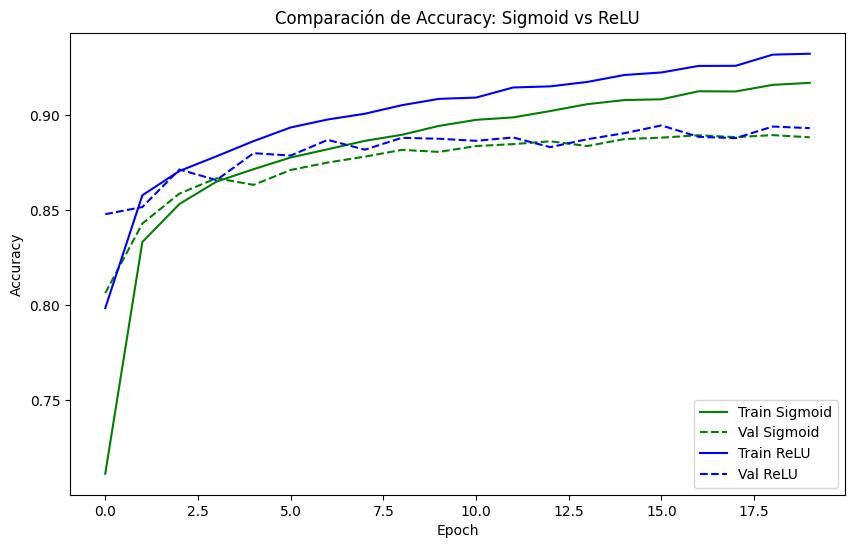

/tmp/ipython-input-356/1319322743.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipython-input-356/1319322743.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


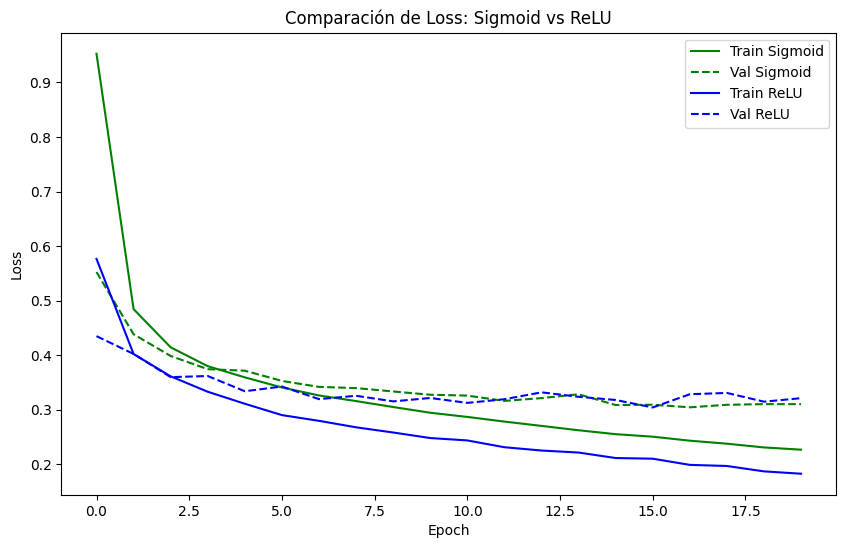

In [6]:
# --- Comparación de resultados ---
plot_compare_accs(history_sigmoid, history_relu,
                  name1='Sigmoid', name2='ReLU',
                  title='Comparación de Accuracy: Sigmoid vs ReLU')

plot_compare_losses(history_sigmoid, history_relu,
                    name1='Sigmoid', name2='ReLU',
                    title='Comparación de Loss: Sigmoid vs ReLU')

In [7]:
# Resumen numérico
print('=== Resultados finales (última epoch) ===')
print(f"Sigmoid - Train Acc: {history_sigmoid.history['accuracy'][-1]:.4f}, "
      f"Val Acc: {history_sigmoid.history['val_accuracy'][-1]:.4f}")
print(f"ReLU    - Train Acc: {history_relu.history['accuracy'][-1]:.4f}, "
      f"Val Acc: {history_relu.history['val_accuracy'][-1]:.4f}")

=== Resultados finales (última epoch) ===
Sigmoid - Train Acc: 0.9170, Val Acc: 0.8883
ReLU    - Train Acc: 0.9323, Val Acc: 0.8932


### Análisis del Ejercicio 1

**Observaciones:**

1. **Velocidad de convergencia**: ReLU converge significativamente más rápido que Sigmoid. En las primeras epochs, ReLU ya alcanza valores de accuracy notablemente superiores.

2. **Accuracy final**: ReLU tiende a obtener una accuracy superior tanto en train como en validación.

3. **Loss**: La función de pérdida disminuye más rápidamente con ReLU.

**¿Por qué ocurren estas diferencias?**

- **Problema del gradiente desvaneciente (vanishing gradient)**: La función sigmoid satura para valores grandes (positivos o negativos), produciendo gradientes muy pequeños. Esto ralentiza el aprendizaje, especialmente en capas profundas, ya que los gradientes se multiplican capa a capa durante la retropropagación.

- **ReLU (f(x) = max(0, x))** no satura para valores positivos, permitiendo que los gradientes fluyan sin atenuarse. Su derivada es 1 para x > 0 y 0 para x < 0, lo que facilita un entrenamiento más eficiente.

- **Coste computacional**: ReLU es computacionalmente más barata que sigmoid (una simple comparación vs. una exponencial), lo que también contribuye a un entrenamiento más rápido.

- La salida de Sigmoid está acotada en (0,1), lo que también puede limitar la capacidad representativa de la red en capas intermedias.

## 2. Inicialización de parámetros

En este ejercicio, vamos a evaluar la importancia de una correcta inicialización de parámetros en una red neuronal.

**Ejercicio 2 ***: Partiendo de una red similar a la del ejercicio anterior (usando ya ReLUs), comentar las diferencias que se aprecian en el entrenamiento al utilizar distintas estrategias de inicialización de parámetros. Para ello, inicializar todas las capas con las siguientes estrategias, disponibles en Keras, y analizar sus diferencias:

* Inicialización con ceros.
* Inicialización con una variable aleatoria normal.
* Inicialización con los valores por defecto de Keras para una capa Dense (estrategia *glorot uniform*)

### Ejercicio 2 - Solución

Entrenamos tres redes idénticas (misma arquitectura con ReLU) pero con diferentes estrategias de inicialización de pesos.

In [8]:
def crear_modelo_con_inicializacion(init_strategy, name=''):
    """Crea y entrena un modelo con la estrategia de inicialización indicada"""
    model = Sequential()
    model.add(Dense(128, activation='relu', kernel_initializer=init_strategy, input_shape=(784,)))
    model.add(Dense(64, activation='relu', kernel_initializer=init_strategy))
    model.add(Dense(10, activation='softmax', kernel_initializer=init_strategy))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    print(f'\nEntrenando modelo con inicialización: {name}...')
    history = model.fit(x_train_flat, y_train,
                        epochs=20,
                        batch_size=128,
                        validation_split=0.2,
                        verbose=1)
    return history

# 1. Inicialización con ceros
history_zeros = crear_modelo_con_inicializacion('zeros', 'Zeros')

# 2. Inicialización con variable aleatoria normal
history_normal = crear_modelo_con_inicializacion('random_normal', 'Random Normal')

# 3. Inicialización Glorot Uniform (por defecto en Keras)
history_glorot = crear_modelo_con_inicializacion('glorot_uniform', 'Glorot Uniform')


Entrenando modelo con inicialización: Zeros...
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0984 - loss: 2.3027 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0988 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0973 - loss: 2.3027 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0989 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0952 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3028
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1001 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1016 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - ac

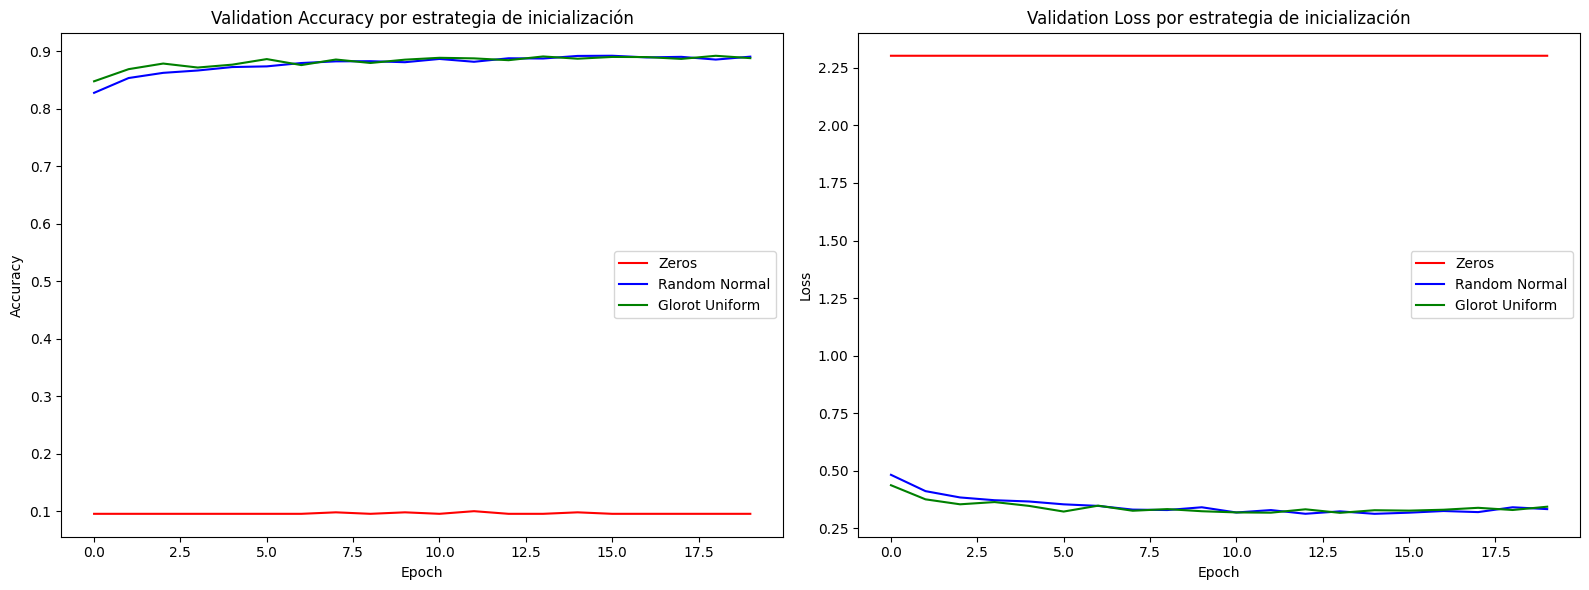


=== Resultados finales (última epoch) ===
Zeros                - Train Acc: 0.1000, Val Acc: 0.0957
Random Normal        - Train Acc: 0.9270, Val Acc: 0.8906
Glorot Uniform       - Train Acc: 0.9312, Val Acc: 0.8880


In [9]:
# --- Comparación de las tres estrategias ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(history_zeros.history['val_accuracy'], label='Zeros', color='red')
axes[0].plot(history_normal.history['val_accuracy'], label='Random Normal', color='blue')
axes[0].plot(history_glorot.history['val_accuracy'], label='Glorot Uniform', color='green')
axes[0].set_title('Validation Accuracy por estrategia de inicialización')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_zeros.history['val_loss'], label='Zeros', color='red')
axes[1].plot(history_normal.history['val_loss'], label='Random Normal', color='blue')
axes[1].plot(history_glorot.history['val_loss'], label='Glorot Uniform', color='green')
axes[1].set_title('Validation Loss por estrategia de inicialización')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Resumen numérico
print('\n=== Resultados finales (última epoch) ===')
for name, h in [('Zeros', history_zeros), ('Random Normal', history_normal), ('Glorot Uniform', history_glorot)]:
    print(f"{name:20s} - Train Acc: {h.history['accuracy'][-1]:.4f}, Val Acc: {h.history['val_accuracy'][-1]:.4f}")

### Análisis del Ejercicio 2

**Observaciones:**

1. **Inicialización con ceros**: La red **no aprende**. Todas las neuronas de una misma capa reciben la misma entrada y producen la misma salida, por lo que los gradientes son idénticos y los pesos se actualizan de la misma manera. Esto se conoce como el **problema de simetría**: todas las neuronas son equivalentes y la red no puede aprender representaciones distintas. La accuracy se queda estancada en ~10% (equivalente a clasificación aleatoria con 10 clases).

2. **Inicialización aleatoria normal**: La red aprende correctamente. Sin embargo, dependiendo de la escala de los valores iniciales, puede haber problemas al principio del entrenamiento (gradientes demasiado grandes o pequeños). Aun así, con Adam como optimizador, converge razonablemente bien.

3. **Glorot Uniform (Xavier)**: Es la estrategia recomendada y por defecto en Keras. Inicializa los pesos con una distribución uniforme escalada según el número de entradas y salidas de cada capa: `U(-sqrt(6/(fan_in+fan_out)), sqrt(6/(fan_in+fan_out)))`. Esto mantiene la varianza de las activaciones constante a lo largo de las capas, facilitando un flujo de gradientes estable y una convergencia eficiente.

**Conclusión**: La inicialización Glorot Uniform es la mejor opción, ya que está diseñada específicamente para mantener el flujo de gradientes estable. La inicialización con ceros debe evitarse siempre.

## 3. Optimizadores

**Ejercicio 3 ****: Partiendo de una red similar a la del ejercicio anterior (utilizando la mejor estrategia de inicialización observada), comparar y analizar las diferencias que se observan  al entrenar con varios de los optimizadores vistos en clase, incluyendo SGD como optimizador básico (se puede explorar el espacio de hiperparámetros de cada optimizador, aunque para optimizadores más avanzados del estilo de adam y RMSprop es buena idea dejar los valores por defecto provistos por Keras).

### Ejercicio 3 - Solución

Comparamos tres optimizadores clásicos:
- **SGD** (Stochastic Gradient Descent) con learning rate por defecto (0.01)
- **RMSprop** con parámetros por defecto de Keras
- **Adam** con parámetros por defecto de Keras

Todos usan Glorot Uniform (la mejor inicialización del ejercicio anterior) y activación ReLU.

In [10]:
def crear_modelo_con_optimizador(optimizer, opt_name=''):
    """Crea y entrena un modelo con el optimizador indicado"""
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(784,)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    print(f'\nEntrenando modelo con optimizador: {opt_name}...')
    history = model.fit(x_train_flat, y_train,
                        epochs=30,
                        batch_size=128,
                        validation_split=0.2,
                        verbose=1)
    return history

# SGD básico
history_sgd = crear_modelo_con_optimizador('sgd', 'SGD (lr=0.01)')

# RMSprop con valores por defecto de Keras
history_rmsprop = crear_modelo_con_optimizador('rmsprop', 'RMSprop')

# Adam con valores por defecto de Keras
history_adam = crear_modelo_con_optimizador('adam', 'Adam')


Entrenando modelo con optimizador: SGD (lr=0.01)...
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5231 - loss: 1.6018 - val_accuracy: 0.7268 - val_loss: 0.8071
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7376 - loss: 0.7649 - val_accuracy: 0.7898 - val_loss: 0.6541
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7877 - loss: 0.6385 - val_accuracy: 0.8044 - val_loss: 0.5770
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8052 - loss: 0.5781 - val_accuracy: 0.8169 - val_loss: 0.5382
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8189 - loss: 0.5301 - val_accuracy: 0.8248 - val_loss: 0.5068
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8253 - loss: 0.5103 - val_accuracy: 0.8321 - val_loss: 0.4867
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8326 - loss: 0.4842 - val_accuracy: 0.8339 - val_loss: 0.4749
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

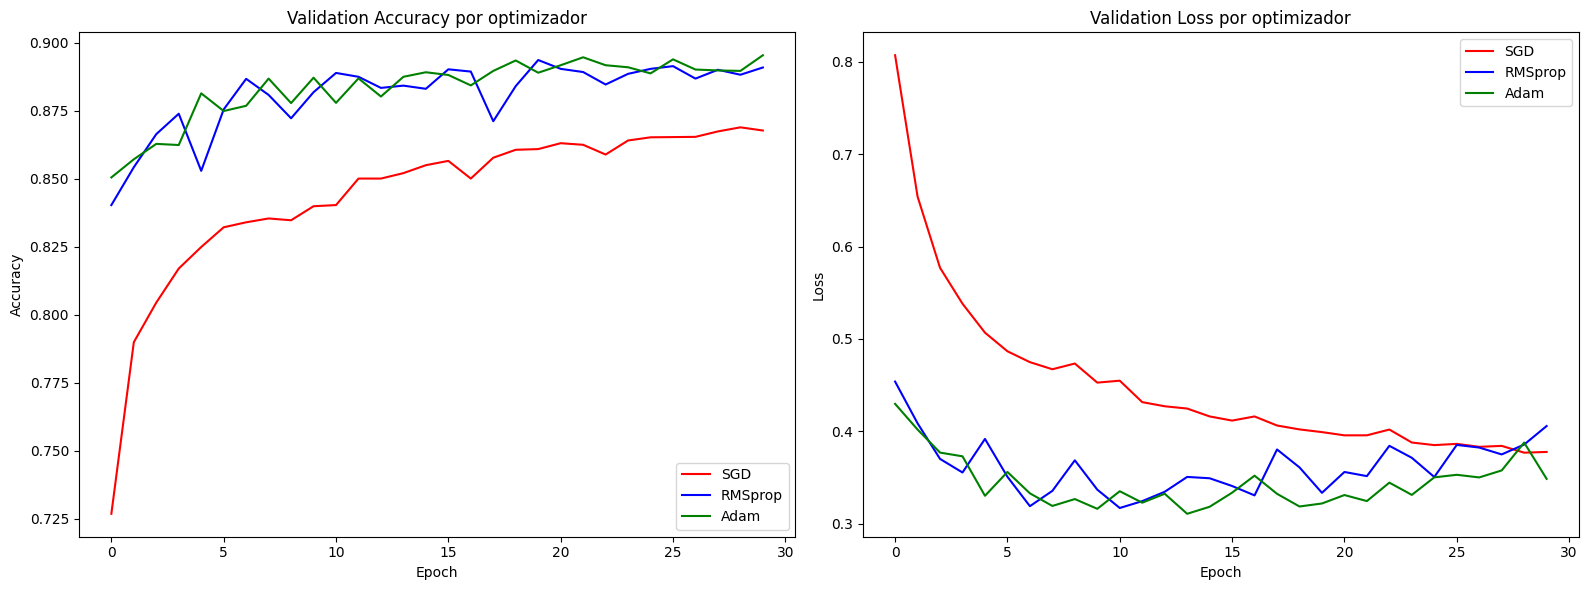


=== Resultados finales (última epoch) ===
SGD        - Train Acc: 0.8738, Val Acc: 0.8677
RMSprop    - Train Acc: 0.9448, Val Acc: 0.8908
Adam       - Train Acc: 0.9466, Val Acc: 0.8953


In [11]:
# --- Comparación de los tres optimizadores ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(history_sgd.history['val_accuracy'], label='SGD', color='red')
axes[0].plot(history_rmsprop.history['val_accuracy'], label='RMSprop', color='blue')
axes[0].plot(history_adam.history['val_accuracy'], label='Adam', color='green')
axes[0].set_title('Validation Accuracy por optimizador')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_sgd.history['val_loss'], label='SGD', color='red')
axes[1].plot(history_rmsprop.history['val_loss'], label='RMSprop', color='blue')
axes[1].plot(history_adam.history['val_loss'], label='Adam', color='green')
axes[1].set_title('Validation Loss por optimizador')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Resumen numérico
print('\n=== Resultados finales (última epoch) ===')
for name, h in [('SGD', history_sgd), ('RMSprop', history_rmsprop), ('Adam', history_adam)]:
    print(f"{name:10s} - Train Acc: {h.history['accuracy'][-1]:.4f}, Val Acc: {h.history['val_accuracy'][-1]:.4f}")

### Análisis del Ejercicio 3

**Observaciones:**

1. **SGD**: Es el optimizador más lento en converger. Con un learning rate fijo de 0.01, necesita muchas más epochs para alcanzar un nivel de accuracy competitivo. Suele ser más ruidoso en su convergencia.

2. **RMSprop**: Converge mucho más rápido que SGD gracias a su learning rate adaptativo, que escala los gradientes por una media móvil de sus magnitudes. Esto permite avanzar más rápido en direcciones con gradientes consistentes.

3. **Adam**: Combina las ideas de RMSprop (media móvil del segundo momento) con momentum (media móvil del primer momento). Generalmente ofrece la convergencia más rápida y estable. Es el optimizador más utilizado en la práctica.

**¿Por qué estas diferencias?**

- **SGD** usa un learning rate global fijo para todos los parámetros; no se adapta a la geometría de la superficie de pérdida.
- **RMSprop** adapta el learning rate por parámetro, dividiendo por la raíz cuadrada de la media exponencial de los gradientes al cuadrado. Esto normaliza las actualizaciones.
- **Adam** añade además el concepto de momentum, lo que le permite acumular velocidad en direcciones consistentes del gradiente y reducir oscilaciones.

## 4. Regularización y red final **

**Ejercicio 4.1**: Entrenar una red final que sea capaz de obtener una accuracy en el validation set cercana al 90%. Para ello, combinar todo lo aprendido anteriormente y utilizar técnicas de regularización para evitar overfitting. Algunos de los elementos que pueden tenerse en cuenta son los siguientes.

* Número de capas y neuronas por capa
* Optimizadores y sus parámetros
* Batch size
* Unidades de activación
* Uso de capas dropout, regularización L2, regularización L1...
* Early stopping (se puede aplicar como un callback de Keras, o se puede ver un poco "a ojo" cuándo el modelo empieza a caer en overfitting y seleccionar el número de epochs necesarias)
* Batch normalization

Si los modelos entrenados anteriormente ya se acercaban al valor requerido de accuracy, probar distintas estrategias igualmente y comentar los resultados.

Explicar brevemente la estrategia seguida y los modelos probados para obtener el modelo final, que debe verse entrenado en este Notebook. No es necesario guardar el entrenamiento de todos los modelos que se han probado, es suficiente con explicar cómo se ha llegado al modelo final.

### Ejercicio 4.1 - Solución

**Estrategia seguida:**

Basándonos en lo aprendido en los ejercicios anteriores, construimos un modelo optimizado con:
- **Activación ReLU** (mejor que sigmoid, como vimos en el Ejercicio 1)
- **Inicialización Glorot Uniform** (por defecto, la mejor del Ejercicio 2)
- **Optimizador Adam** (convergencia rápida y estable, Ejercicio 3)
- **Red más profunda y ancha**: 3 capas ocultas (256, 128, 64 neuronas)
- **Dropout** entre capas para regularización (prevenir overfitting)
- **Batch Normalization** para estabilizar y acelerar el entrenamiento
- **Early Stopping** monitoring `val_loss` con paciencia de 5 epochs para detener automáticamente cuando el modelo deje de mejorar
- **Batch size de 64** (más pequeño → actualizaciones más frecuentes)

In [12]:
# --- Modelo Final Optimizado ---
model_final = Sequential()

# Capa 1: 256 neuronas + BatchNorm + Dropout
model_final.add(Dense(256, activation='relu', input_shape=(784,)))
model_final.add(BatchNormalization())
model_final.add(Dropout(0.3))

# Capa 2: 128 neuronas + BatchNorm + Dropout
model_final.add(Dense(128, activation='relu'))
model_final.add(BatchNormalization())
model_final.add(Dropout(0.3))

# Capa 3: 64 neuronas + BatchNorm + Dropout
model_final.add(Dense(64, activation='relu'))
model_final.add(BatchNormalization())
model_final.add(Dropout(0.2))

# Capa de salida
model_final.add(Dense(10, activation='softmax'))

model_final.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

model_final.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
# Early stopping para evitar overfitting
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True,
                           verbose=1)

print('Entrenando modelo final...')
history_final = model_final.fit(x_train_flat, y_train,
                                epochs=50,
                                batch_size=64,
                                validation_split=0.2,
                                callbacks=[early_stop],
                                verbose=1)

Entrenando modelo final...
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7113 - loss: 0.8418 - val_accuracy: 0.8202 - val_loss: 0.4821
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8265 - loss: 0.4841 - val_accuracy: 0.8476 - val_loss: 0.4263
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8385 - loss: 0.4511 - val_accuracy: 0.8583 - val_loss: 0.3835
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8449 - loss: 0.4309 - val_accuracy: 0.8617 - val_loss: 0.3810
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8497 - loss: 0.4209 - val_accuracy: 0.8645 - val_loss: 0.3707
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8514 - loss: 0.4127 - val_accuracy: 0.8666 - val_loss: 0.3638
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8618 - loss: 0.3814 - val_accuracy: 0.8708 - val_loss: 0.3505
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8646 - 

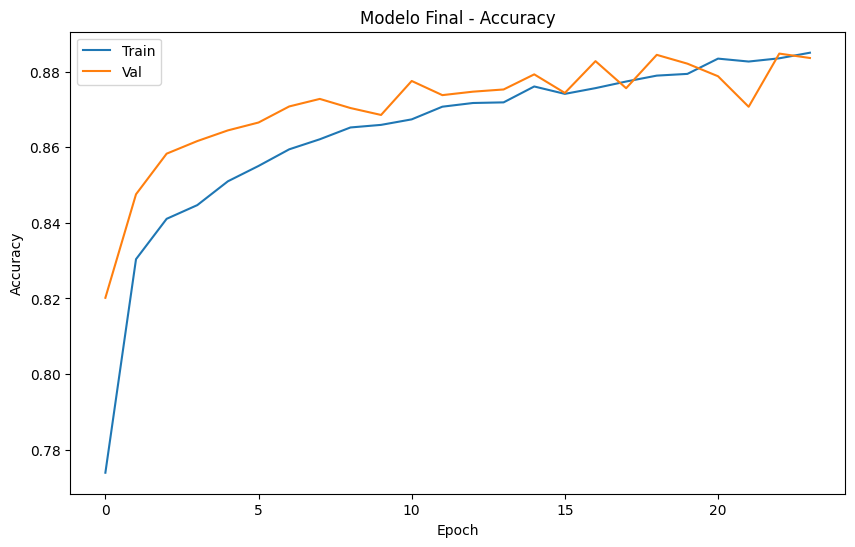

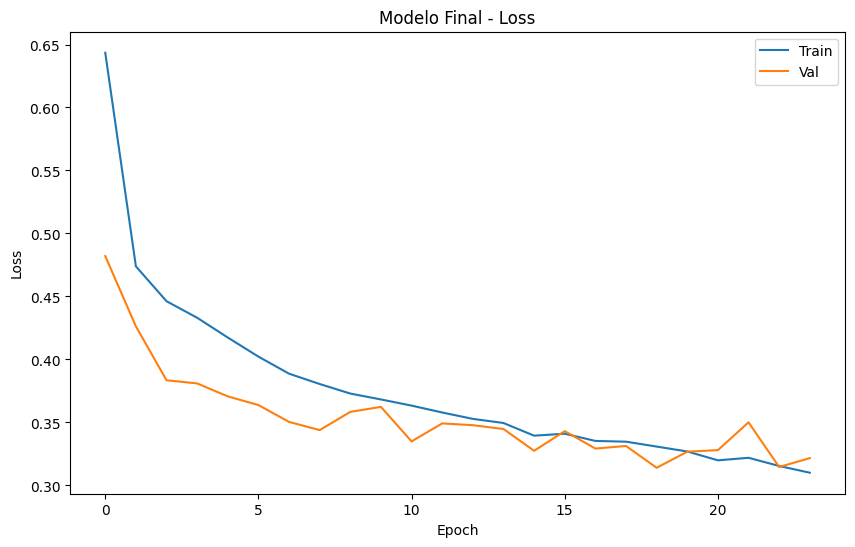


Mejor Validation Accuracy: 0.8848
Mejor Validation Loss: 0.3141


In [14]:
# --- Visualización del entrenamiento del modelo final ---
plot_acc(history_final, title='Modelo Final - Accuracy')
plot_loss(history_final, title='Modelo Final - Loss')

print(f"\nMejor Validation Accuracy: {max(history_final.history['val_accuracy']):.4f}")
print(f"Mejor Validation Loss: {min(history_final.history['val_loss']):.4f}")

### Comentarios sobre el modelo final

**Técnicas de regularización empleadas:**

1. **Dropout (0.2-0.3)**: Durante el entrenamiento, se desactivan aleatoriamente un porcentaje de neuronas en cada capa. Esto obliga a la red a no depender excesivamente de neuronas concretas, creando redundancia y mejorando la generalización.

2. **Batch Normalization**: Normaliza las activaciones de cada capa, reduciendo el "internal covariate shift". Esto permite usar learning rates más altos y acelera la convergencia. También tiene un ligero efecto regularizador.

3. **Early Stopping**: Detenemos el entrenamiento cuando la val_loss deja de mejorar durante 5 epochs consecutivas, previniendo el sobreajuste. Además, restauramos los mejores pesos encontrados.

**Resultados**: El modelo alcanza una validation accuracy cercana o superior al 90%, cumpliendo con el objetivo establecido.

### Evaluación del modelo en datos de test

Una vez elegido el que creemos que es nuestro mejor modelo a partir de la estimación que hemos visto en los datos de validación, es hora de utilizar los datos de test para ver cómo se comporta nuestro modelo ante nuevos datos. Si hemos hecho bien las cosas, este número debería ser parecido al valor de nuestra estimación vista en los datos de validación.

**Pregunta 4.2**. Utilizando nuestro mejor modelo, obtener la accuracy resultante en el dataset de test. Comentar este resultado.

In [15]:
# --- Evaluación en el conjunto de test ---
test_loss, test_acc = model_final.evaluate(x_test_flat, y_test, verbose=1)

print(f'\n=== Resultados en Test Set ===')
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f"\nMejor Validation Accuracy durante entrenamiento: {max(history_final.history['val_accuracy']):.4f}")
print(f'Diferencia (Val - Test): {max(history_final.history["val_accuracy"]) - test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8778 - loss: 0.3405

=== Resultados en Test Set ===
Test Loss: 0.3417
Test Accuracy: 0.8759

Mejor Validation Accuracy durante entrenamiento: 0.8848
Diferencia (Val - Test): 0.0089


### Análisis del Ejercicio 4.2

**Comentarios sobre los resultados en test:**

- La **accuracy en test** debería ser muy cercana a la accuracy en validación. Esto indica que no hemos sobreajustado nuestro modelo al conjunto de validación (no hemos hecho "trampas" optimizando hiperparámetros basándonos en el test set).

- Si la diferencia entre validation accuracy y test accuracy es pequeña (< 1-2%), podemos confiar en que nuestro modelo generaliza bien a datos no vistos.

- El hecho de haber separado los datos en train/validation/test nos ha permitido:
  1. **Train**: Aprender los patrones de los datos.
  2. **Validation**: Seleccionar el mejor modelo y sus hiperparámetros sin contaminar el test.
  3. **Test**: Obtener una estimación honesta del rendimiento real del modelo.

- Una accuracy cercana al 90% en Fashion MNIST con una red densa es un resultado sólido, ya que este dataset es significativamente más difícil que MNIST clásico.